In [1]:
#1.Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, auc)

sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
#2.Load Dataset
df = pd.read_csv("../data/vanet_traffic_data_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (195714, 29)


,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,signal_state_num,incident_num,...,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label,hour_of_day,day_of_week,is_rush_hour,network_reliability_score
0,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,2.065,0.510,...,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate,4,0,0,10.726
1,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,3.971,2.088,...,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock,6,1,0,50.785
2,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,2.033,0.437,...,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate,5,0,0,9.553
3,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,1.943,0.467,...,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate,21,6,0,10.264
4,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,0.937,-0.101,...,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow,0,6,0,2.400


In [3]:
#3.Encode Target, Split, Scale
y = df["label"]
X = df.drop(columns=["label"])
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print("Classes:", class_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled = scaler.transform(X_test)          # transform test using train's scaler

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Classes: ['Free-flow' 'Gridlock' 'Heavy' 'Moderate']
X_train_scaled: (156571, 28)
X_test_scaled: (39143, 28)


In [4]:
#4.Reusable Evaluation Function
# We'll reuse this for every model so metrics are calculated the exact same way each time
results = []  # will store one row per model for the final comparison table

def evaluate_model(name, model, X_test_, y_test_, y_proba):
    y_pred = model.predict(X_test_)
    
    acc = accuracy_score(y_test_, y_pred)
    prec = precision_score(y_test_, y_pred, average="weighted")
    rec = recall_score(y_test_, y_pred, average="weighted")
    f1 = f1_score(y_test_, y_pred, average="weighted")
    auc_score = roc_auc_score(y_test_, y_proba, multi_class="ovr", average="weighted")
    cm = confusion_matrix(y_test_, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc_score:.4f}")
    
    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-score": f1, "ROC-AUC": auc_score
    })
    return y_pred, cm

In [ ]:
#5.Algorithm1:Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_proba_lr = logreg.predict_proba(X_test_scaled)
y_pred_lr, cm_lr = evaluate_model("Logistic Regression", logreg, X_test_scaled, y_test, y_proba_lr)

--- Logistic Regression ---
Accuracy:  0.9906
Precision: 0.9906
Recall:    0.9906
F1-score:  0.9906
ROC-AUC:   0.9958


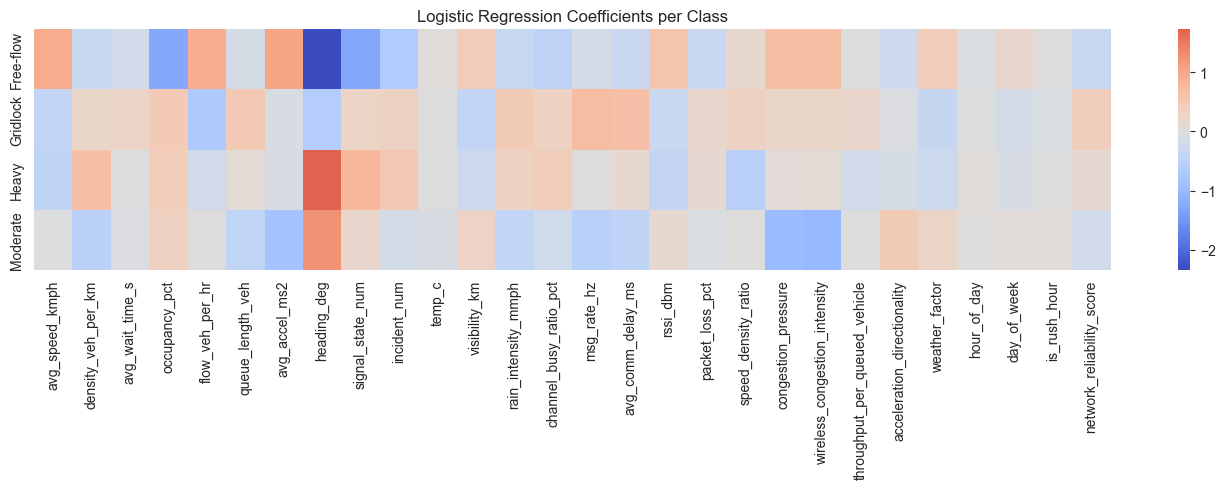

Free-flow: strongest driver = heading_deg (coef = -2.335)
Gridlock: strongest driver = flow_veh_per_hr (coef = -0.726)
Heavy: strongest driver = heading_deg (coef = 1.723)
Moderate: strongest driver = heading_deg (coef = 1.237)


In [6]:
## Interpret coefficients: which features push predictions toward each class?
coef_df = pd.DataFrame(logreg.coef_, columns=X.columns, index=class_names)

plt.figure(figsize=(14,5))
sns.heatmap(coef_df, cmap="coolwarm", center=0, annot=False)
plt.title("Logistic Regression Coefficients per Class")
plt.tight_layout()
plt.show()

# Show the strongest coefficient for each class
for c in class_names:
    top_feat = coef_df.loc[c].abs().idxmax()
    print(f"{c}: strongest driver = {top_feat} (coef = {coef_df.loc[c, top_feat]:.3f})")

k=3: accuracy=0.9902
k=5: accuracy=0.9906
k=7: accuracy=0.9906
k=9: accuracy=0.9906
k=11: accuracy=0.9906
k=15: accuracy=0.9906


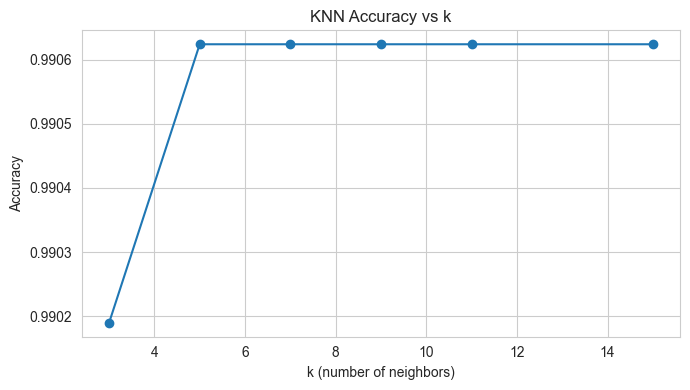

In [7]:
#6.Algorithm2:K-Nearest Neighbors
# Tune k: try several values and track accuracy
k_values = [3, 5, 7, 9, 11, 15]
k_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    k_scores.append(acc)
    print(f"k={k}: accuracy={acc:.4f}")

plt.figure(figsize=(7,4))
plt.plot(k_values, k_scores, marker='o')
plt.title("KNN Accuracy vs k")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

In [8]:
# Train final KNN with best k
best_k = k_values[np.argmax(k_scores)]
print("Best k:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_proba_knn = knn.predict_proba(X_test_scaled)
y_pred_knn, cm_knn = evaluate_model(f"KNN (k={best_k})", knn, X_test_scaled, y_test, y_proba_knn)

Best k: 5
--- KNN (k=5) ---
Accuracy:  0.9906
Precision: 0.9906
Recall:    0.9906
F1-score:  0.9906
ROC-AUC:   0.9937


In [9]:
#7.Algorithm3-Naive Bayes (Gaussian)
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_proba_nb = nb.predict_proba(X_test_scaled)
y_pred_nb, cm_nb = evaluate_model("Naive Bayes", nb, X_test_scaled, y_test, y_proba_nb)

--- Naive Bayes ---
Accuracy:  0.9906
Precision: 0.9906
Recall:    0.9906
F1-score:  0.9906
ROC-AUC:   0.9949


In [10]:
#8.Algorithm:4-Decision Tree (tune max_depth, visualize)
# Tune max_depth with GridSearchCV
param_grid = {"max_depth": [3, 5, 7, 10, 15, None]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted"
)
grid_dt.fit(X_train_scaled, y_train)

print("Best max_depth:", grid_dt.best_params_)
print("Best CV F1-score:", grid_dt.best_score_)

Best max_depth: {'max_depth': 3}
Best CV F1-score: 0.9898206568861082


In [11]:
dt = grid_dt.best_estimator_
y_proba_dt = dt.predict_proba(X_test_scaled)
y_pred_dt, cm_dt = evaluate_model("Decision Tree", dt, X_test_scaled, y_test, y_proba_dt)

--- Decision Tree ---
Accuracy:  0.9906
Precision: 0.9906
Recall:    0.9906
F1-score:  0.9906
ROC-AUC:   0.9959


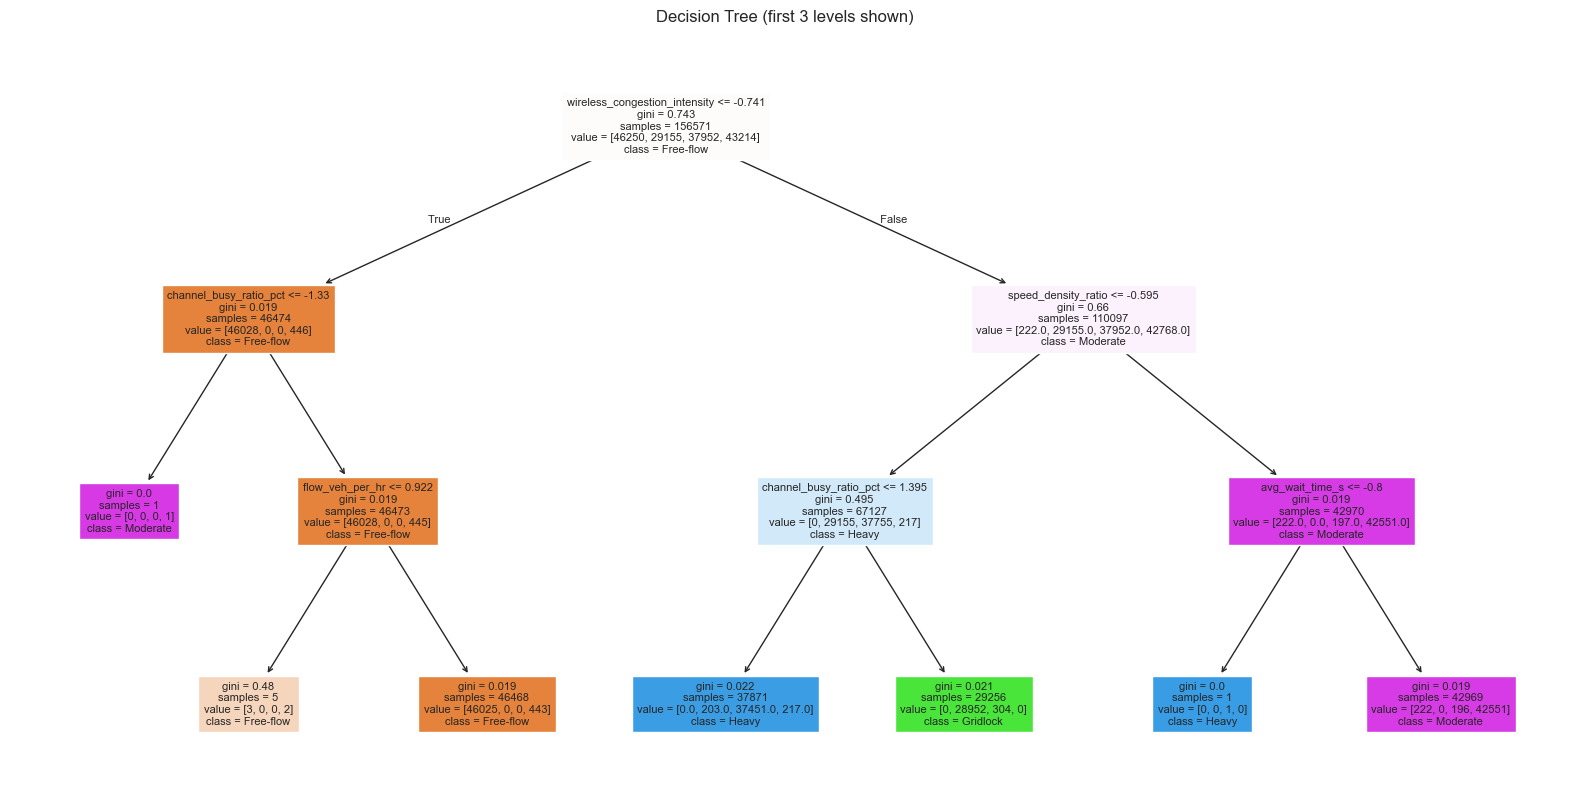

In [12]:
# Visualize the tree (limited to depth 3 for readability — full tree is too large to plot clearly)
plt.figure(figsize=(20,10))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=class_names, 
          filled=True, fontsize=8)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()

C:\Users\manin\AppData\Local\Temp\ipykernel_13792\867717962.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


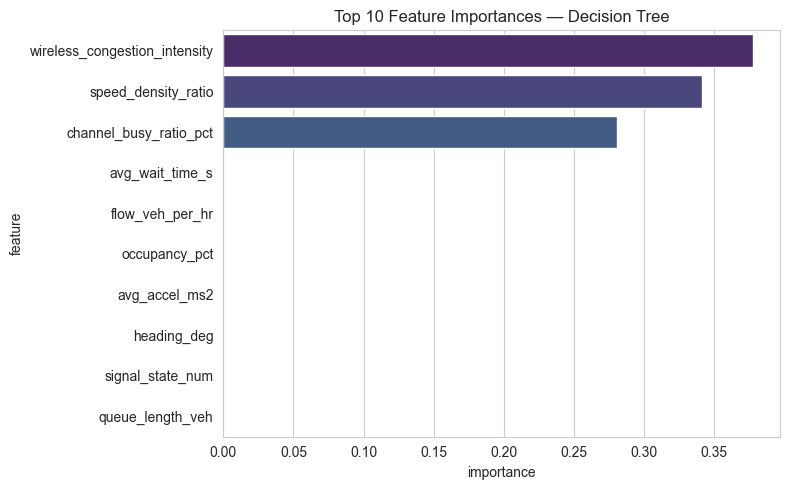

In [13]:
# Feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Top 10 Feature Importances — Decision Tree")
plt.tight_layout()
plt.show()

In [14]:
#9.Algorithm:5-SVM
# SVM is computationally expensive on 150k+ rows, especially with probability=True (needed for ROC-AUC).
# We train on a stratified subsample of the training data to keep runtime reasonable —
# a standard, defensible practice for large datasets in a capstone project.

from sklearn.model_selection import train_test_split as tts

X_train_sub, _, y_train_sub, _ = tts(
    X_train_scaled, y_train, train_size=8000, random_state=42, stratify=y_train
)
print("SVM training subsample size:", X_train_sub.shape)

SVM training subsample size: (8000, 28)


In [15]:
# Small tuning grid: kernel and C
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=3,
    scoring="f1_weighted"
)
grid_svm.fit(X_train_sub, y_train_sub)

print("Best params:", grid_svm.best_params_)
print("Best CV F1-score:", grid_svm.best_score_)

Best params: {'C': 0.1, 'kernel': 'linear'}
Best CV F1-score: 0.9909973830146801


In [16]:
svm = grid_svm.best_estimator_

# Evaluate on the FULL test set (evaluation isn't limited by the training subsample)
y_proba_svm = svm.predict_proba(X_test_scaled)
y_pred_svm, cm_svm = evaluate_model("SVM", svm, X_test_scaled, y_test, y_proba_svm)

--- SVM ---
Accuracy:  0.9906
Precision: 0.9906
Recall:    0.9906
F1-score:  0.9906
ROC-AUC:   0.9958


In [17]:
#10.Comparison Table
results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.990624,0.990625,0.990624,0.990619,0.995844
1,KNN (k=5),0.990624,0.990625,0.990624,0.990619,0.993653
2,Naive Bayes,0.990624,0.990625,0.990624,0.990619,0.994858
3,SVM,0.990624,0.990625,0.990624,0.990619,0.995809
4,Decision Tree,0.990599,0.990599,0.990599,0.990593,0.995944


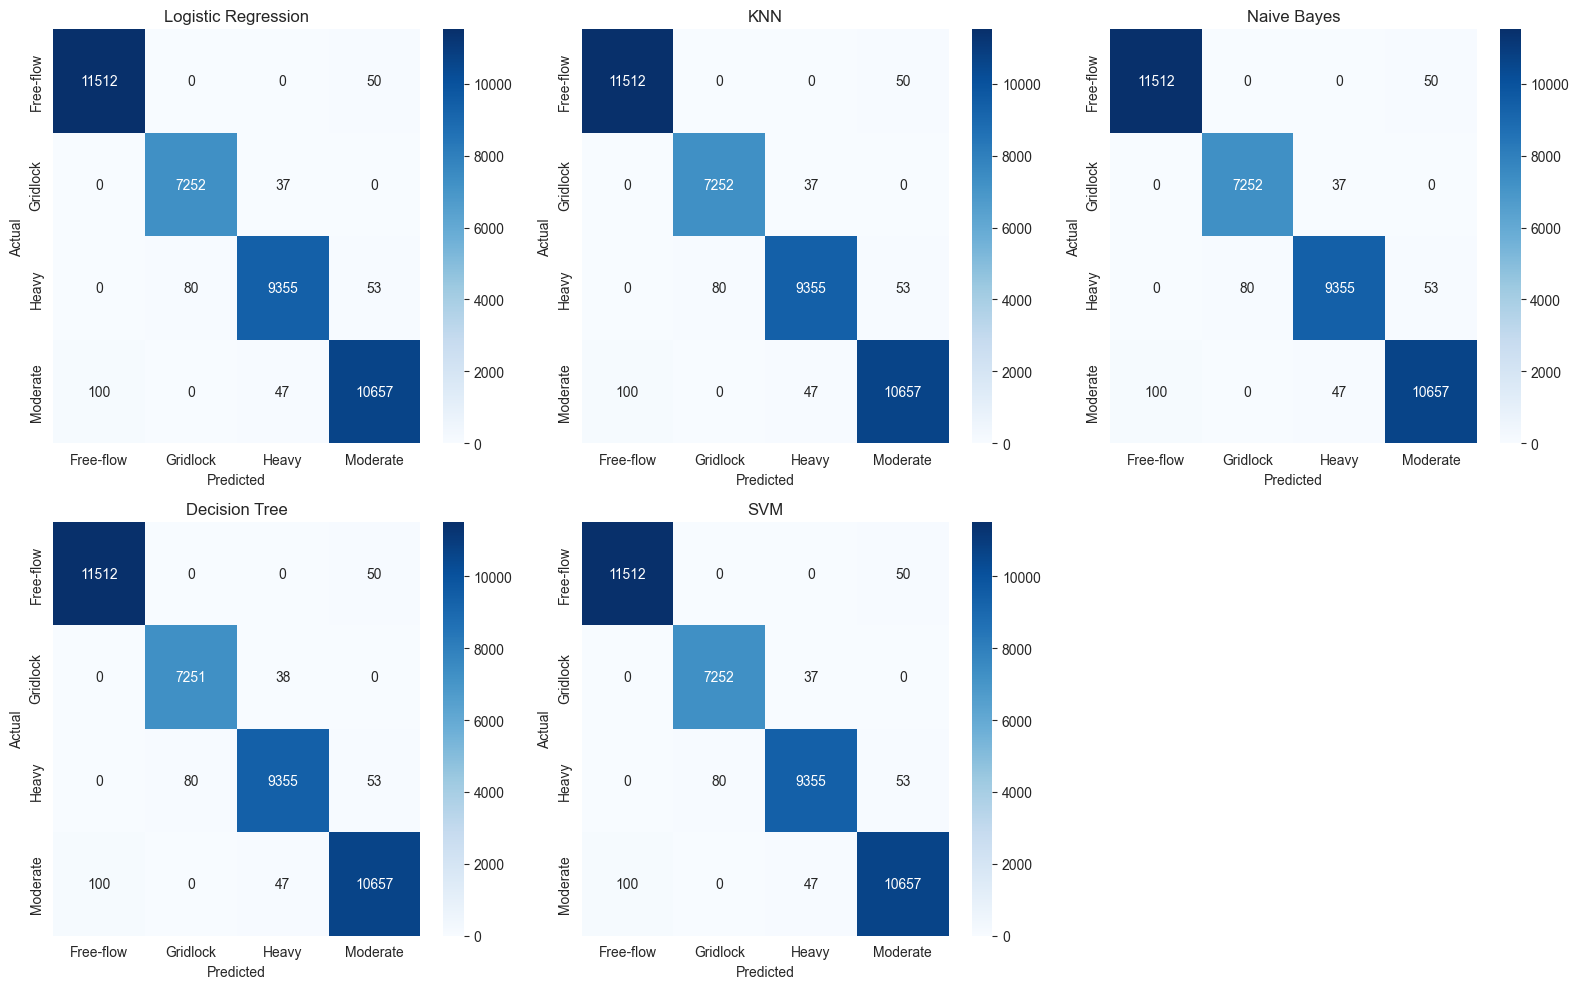

In [19]:
#11.Confusion Matrix for all five algorithms
models_cm = {
    "Logistic Regression": cm_lr,
    "KNN": cm_knn,
    "Naive Bayes": cm_nb,
    "Decision Tree": cm_dt,
    "SVM": cm_svm
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, models_cm.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis("off")  # hide the unused 6th subplot
plt.tight_layout()
plt.show()

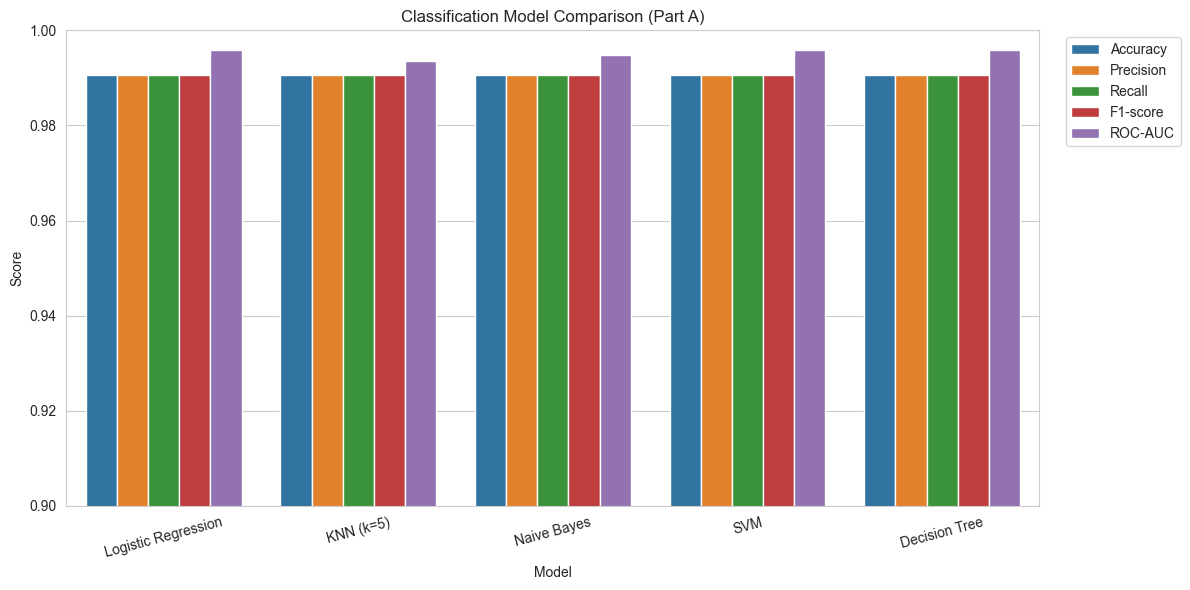

In [20]:
#13.Metric Comparison Bar Chart
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
plot_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot, 
                            var_name="Metric", value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="tab10")
plt.title("Classification Model Comparison (Part A)")
plt.ylim(0.9, 1.0)  # zoom in since all scores are high
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
#14.Save Models
os.makedirs("../models", exist_ok=True)

joblib.dump(logreg, "../models/logistic_regression.pkl")
joblib.dump(knn, "../models/knn.pkl")
joblib.dump(nb, "../models/naive_bayes.pkl")
joblib.dump(dt, "../models/decision_tree.pkl")
joblib.dump(svm, "../models/svm.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("All  models saved to ../models/")

All  models saved to ../models/
